In [ ]:
import os
import zipfile
from google.colab import drive

# Gắn kết Google Drive để lấy file nén
drive.mount('/content/drive')

# Cấu hình các biến hằng số đường dẫn
ZIP_FILE_PATH = '/content/drive/MyDrive/dataset.zip'
EXTRACTION_DIR = '/content/dataset_temp'
DATA_ROOT = os.path.join(EXTRACTION_DIR, "dataset_7_5_26")

# Giải nén toàn bộ dữ liệu nếu thư mục chưa tồn tại
if not os.path.exists(EXTRACTION_DIR):
    print("Bắt đầu giải nén dữ liệu...")
    os.makedirs(EXTRACTION_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACTION_DIR)
    print("Hoàn tất giải nén.")
else:
    print("Dữ liệu đã được giải nén từ trước.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dữ liệu đã được giải nén từ trước.


KHỞI TẠO MODEL

In [ ]:
import torch
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

# ID của mô hình trên HuggingFace
MODEL_ID = "google/paligemma-3b-pt-224"

print("Đang tải bộ xử lý (Processor)...")
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)

print("Đang tải mô hình (Model) vào GPU...")
# Sử dụng bfloat16 tương thích với cấu trúc của A100
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# Đặt mô hình ở chế độ đánh giá (evaluation) để tắt Dropout và Batch Normalization
model.eval()
print("Sẵn sàng.")

Đang tải bộ xử lý (Processor)...


preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Sẵn sàng.


CÁC HÀM XỬ LÝ

In [ ]:
from PIL import Image

def parse_image_path(csv_path, label, split_name):
    """
    Hàm phân tích chuỗi đường dẫn từ CSV và ghép nối với cấu trúc thư mục thực tế.
    Ví dụ: csv_path = "animal_dataset/animals/animals/antelope/antelope_23.jpg"
    Trả về: "/content/dataset_temp/dataset_7_5_26/test/antelope/antelope_23.jpg"
    """
    # Lấy tên file gốc
    file_name = os.path.basename(csv_path)
    # Nối với đường dẫn chuẩn trên Colab
    return os.path.join(DATA_ROOT, split_name, label, file_name)

def generate_vqa_answer(image_path, question):
    """
    Hàm xử lý đa phương thức (hình ảnh và văn bản) và sinh chuỗi trả lời.
    """
    # Mở ảnh và chuyển về hệ màu RGB chuẩn
    image = Image.open(image_path).convert("RGB")

    # Định dạng chuỗi đầu vào theo tiêu chuẩn của PaliGemma
    prompt = f"vqa {question}\n"

    # Tiền xử lý dữ liệu và đẩy lên GPU
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

    # Chuyển đổi kiểu dữ liệu ảnh (float32) sang bfloat16 để đồng bộ với mô hình
    inputs = {k: v.to(torch.bfloat16) if v.dtype == torch.float32 else v for k, v in inputs.items()}

    # Quá trình sinh văn bản (không tính toán gradient để tiết kiệm VRAM)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20, # Đủ để sinh ra dưới 10 từ tiếng Việt
            do_sample=False     # Sử dụng Greedy Decoding
        )

    # Giải mã vector thành chuỗi văn bản và loại bỏ các token đặc biệt
    decoded_text = processor.decode(outputs[0], skip_special_tokens=True)

    # Trích xuất phần câu trả lời (loại bỏ phần câu hỏi ở đầu chuỗi)
    answer = decoded_text[len(prompt):].strip()
    return answer

In [ ]:
# =================================================================
# CELL 5: THỰC THI TRÊN TẬP KIỂM THỬ (TEST SET) VÀ LƯU KẾT QUẢ
# =================================================================
import pandas as pd
from tqdm import tqdm
import os

# Đọc dữ liệu kiểm thử
test_csv_path = os.path.join(DATA_ROOT, "test.csv")
test_df = pd.read_csv(test_csv_path)

results = []
error_count = 0

print(f"Bắt đầu quá trình Zero-shot Inference trên {len(test_df)} mẫu...")

# Lặp qua từng dòng dữ liệu trong DataFrame
for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
    image_path_in_csv = row['image_path']
    label = row['label']
    question = row['question']
    ground_truth = row['answer']
    question_type = row['q_type']

    # Tạo đường dẫn vật lý thực tế cho tập 'test'
    absolute_image_path = parse_image_path(image_path_in_csv, label, 'test')

    try:
        # Gọi hàm nội suy để sinh câu trả lời
        predicted_answer = generate_vqa_answer(absolute_image_path, question)

        # Lưu kết quả vào danh sách bộ nhớ tạm
        results.append({
            "image_path": image_path_in_csv,
            "label": label,
            "question": question,
            "q_type": question_type,
            "ground_truth": ground_truth,
            "prediction": predicted_answer
        })
    except Exception as e:
        error_count += 1
        print(f"\nLỗi tại dòng {index} (File: {image_path_in_csv}): {str(e)}")

print(f"Hoàn tất. Có {error_count} mẫu bị lỗi trong quá trình xử lý.")

# Cấu hình đường dẫn thư mục lưu trữ trên Google Drive
output_directory = "/content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1"

# Tự động tạo thư mục nếu chưa tồn tại (exist_ok=True giúp bỏ qua lỗi nếu thư mục đã có)
os.makedirs(output_directory, exist_ok=True)

# Khai báo đường dẫn đầy đủ của tệp tin CSV cấu thành từ thư mục và tên file
output_csv_path = os.path.join(output_directory, "B1_ZeroShot_Results.csv")

# Chuyển đổi danh sách kết quả thành DataFrame và xuất ra định dạng CSV
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv_path, index=False)

print(f"Kết quả dự đoán đã được lưu thành công tại: {output_csv_path}")

Bắt đầu quá trình Zero-shot Inference trên 3240 mẫu...


  0%|          | 1/3240 [00:01<1:37:17,  1.80s/it][transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
  0%|          | 3/3240 [00:02<34:00,  1.59it/s]  [transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended

Hoàn tất. Có 0 mẫu bị lỗi trong quá trình xử lý.
Kết quả dự đoán đã được lưu thành công tại: /content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv


In [ ]:
import pandas as pd
import string
import numpy as np
import evaluate
from tqdm import tqdm

# Khởi tạo các module đánh giá từ Hugging Face
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

def normalize_text(text):
    """
    Chuẩn hóa văn bản tiếng Việt: Chuyển chữ thường, xóa khoảng trắng thừa
    và loại bỏ toàn bộ dấu câu để tính Exact Match công bằng.
    """
    text = str(text).lower().strip()
    # Loại bỏ dấu câu bằng bảng biến đổi mã ký tự
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Loại bỏ khoảng trắng kép
    return " ".join(text.split())

def calculate_token_f1(prediction, ground_truth):
    """
    Tính toán Soft Match (F1-Score) dựa trên mức độ trùng lặp từ vựng.
    """
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()

    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)

    common_tokens = set(pred_tokens).intersection(set(gt_tokens))
    if len(common_tokens) == 0:
        return 0.0

    precision = len(common_tokens) / len(pred_tokens)
    recall = len(common_tokens) / len(gt_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def run_evaluation(csv_path):
    print(f"Đang tải kết quả từ: {csv_path}")
    df = pd.read_csv(csv_path)

    # 1. Tiền xử lý dữ liệu đầu vào cho các hàm đánh giá
    predictions = df['prediction'].astype(str).tolist()
    references = df['ground_truth'].astype(str).tolist()

    # Chuẩn hóa để tính Accuracy
    norm_preds = [normalize_text(p) for p in predictions]
    norm_refs = [normalize_text(r) for r in references]

    print("\n[1/4] Đang tính toán VQA Accuracy (Exact Match & Soft Match/F1)...")
    exact_matches = [int(p == r) for p, r in zip(norm_preds, norm_refs)]
    soft_matches = [calculate_token_f1(p, r) for p, r in zip(norm_preds, norm_refs)]

    exact_match_acc = np.mean(exact_matches) * 100
    soft_match_acc = np.mean(soft_matches) * 100

    print("[2/4] Đang tính toán BLEU và METEOR...")
    # BLEU yêu cầu danh sách các tham chiếu (references) dưới dạng list of lists
    bleu_refs = [[r] for r in references]
    bleu_results = bleu_metric.compute(predictions=predictions, references=bleu_refs)
    meteor_results = meteor_metric.compute(predictions=predictions, references=references)

    print("[3/4] Đang tính toán ROUGE-L...")
    rouge_results = rouge_metric.compute(predictions=predictions, references=references)

    print("[4/4] Đang tính toán BERTScore (Sử dụng pre-trained model cho tiếng Việt)...")
    # Sử dụng lang="vi" để thư viện tự động tải multilingual model phù hợp
    bertscore_results = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="vi"
    )

    # BERTScore trả về một mảng điểm cho từng câu, ta tính trung bình
    bert_precision = np.mean(bertscore_results['precision']) * 100
    bert_recall = np.mean(bertscore_results['recall']) * 100
    bert_f1 = np.mean(bertscore_results['f1']) * 100

    # ==========================================
    # TỔNG HỢP VÀ IN KẾT QUẢ
    # ==========================================
    print("\n" + "="*50)
    print("BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS)")
    print("="*50)
    print(f"Tập dữ liệu        : {len(df)} mẫu")
    print("-" * 50)
    print(f"1. VQA Exact Match : {exact_match_acc:.2f} %")
    print(f"2. VQA Soft Match  : {soft_match_acc:.2f} % (Token F1)")
    print("-" * 50)
    print(f"3. BLEU-4 Score    : {bleu_results['bleu'] * 100:.2f}")
    print(f"4. METEOR Score    : {meteor_results['meteor'] * 100:.2f}")
    print(f"5. ROUGE-L Score   : {rouge_results['rougeL'] * 100:.2f}")
    print("-" * 50)
    print("6. BERTScore (Ngữ nghĩa):")
    print(f"   - Precision     : {bert_precision:.2f}")
    print(f"   - Recall        : {bert_recall:.2f}")
    print(f"   - F1            : {bert_f1:.2f}")
    print("="*50)

# Thực thi hàm đánh giá
OUTPUT_CSV = "/content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv"
run_evaluation(OUTPUT_CSV)

In [ ]:
import pandas as pd
import string
import numpy as np
import evaluate
from tqdm import tqdm

# Khởi tạo các module đánh giá từ Hugging Face
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

def normalize_text(text):
    """
    Chuẩn hóa văn bản tiếng Việt: Chuyển chữ thường, xóa khoảng trắng thừa
    và loại bỏ toàn bộ dấu câu để tính Exact Match công bằng.
    """
    text = str(text).lower().strip()
    # Loại bỏ dấu câu bằng bảng biến đổi mã ký tự
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Loại bỏ khoảng trắng kép
    return " ".join(text.split())

def calculate_token_f1(prediction, ground_truth):
    """
    Tính toán Soft Match (F1-Score) dựa trên mức độ trùng lặp từ vựng.
    """
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()

    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)

    common_tokens = set(pred_tokens).intersection(set(gt_tokens))
    if len(common_tokens) == 0:
        return 0.0

    precision = len(common_tokens) / len(pred_tokens)
    recall = len(common_tokens) / len(gt_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def run_evaluation(csv_path):
    print(f"Đang tải kết quả từ: {csv_path}")
    df = pd.read_csv(csv_path)

    # 1. Tiền xử lý dữ liệu đầu vào cho các hàm đánh giá
    predictions = df['prediction'].astype(str).tolist()
    references = df['ground_truth'].astype(str).tolist()

    # Chuẩn hóa để tính Accuracy
    norm_preds = [normalize_text(p) for p in predictions]
    norm_refs = [normalize_text(r) for r in references]

    print("\n[1/4] Đang tính toán VQA Accuracy (Exact Match & Soft Match/F1)...")
    exact_matches = [int(p == r) for p, r in zip(norm_preds, norm_refs)]
    soft_matches = [calculate_token_f1(p, r) for p, r in zip(norm_preds, norm_refs)]

    exact_match_acc = np.mean(exact_matches) * 100
    soft_match_acc = np.mean(soft_matches) * 100

    print("[2/4] Đang tính toán BLEU và METEOR...")
    # BLEU yêu cầu danh sách các tham chiếu (references) dưới dạng list of lists
    bleu_refs = [[r] for r in references]
    bleu_results = bleu_metric.compute(predictions=predictions, references=bleu_refs)
    meteor_results = meteor_metric.compute(predictions=predictions, references=references)

    print("[3/4] Đang tính toán ROUGE-L...")
    rouge_results = rouge_metric.compute(predictions=predictions, references=references)

    print("[4/4] Đang tính toán BERTScore (Sử dụng pre-trained model cho tiếng Việt)...")
    # Sử dụng lang="vi" để thư viện tự động tải multilingual model phù hợp
    bertscore_results = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="vi"
    )

    # BERTScore trả về một mảng điểm cho từng câu, ta tính trung bình
    bert_precision = np.mean(bertscore_results['precision']) * 100
    bert_recall = np.mean(bertscore_results['recall']) * 100
    bert_f1 = np.mean(bertscore_results['f1']) * 100

    # ==========================================
    # TỔNG HỢP VÀ IN KẾT QUẢ
    # ==========================================
    print("\n" + "="*50)
    print("BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS)")
    print("="*50)
    print(f"Tập dữ liệu        : {len(df)} mẫu")
    print("-" * 50)
    print(f"1. VQA Exact Match : {exact_match_acc:.2f} %")
    print(f"2. VQA Soft Match  : {soft_match_acc:.2f} % (Token F1)")
    print("-" * 50)
    print(f"3. BLEU-4 Score    : {bleu_results['bleu'] * 100:.2f}")
    print(f"4. METEOR Score    : {meteor_results['meteor'] * 100:.2f}")
    print(f"5. ROUGE-L Score   : {rouge_results['rougeL'] * 100:.2f}")
    print("-" * 50)
    print("6. BERTScore (Ngữ nghĩa):")
    print(f"   - Precision     : {bert_precision:.2f}")
    print(f"   - Recall        : {bert_recall:.2f}")
    print(f"   - F1            : {bert_f1:.2f}")
    print("="*50)

# Thực thi hàm đánh giá
OUTPUT_CSV = "/content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv"
run_evaluation(OUTPUT_CSV)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Đang tải kết quả từ: /content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv

[1/4] Đang tính toán VQA Accuracy (Exact Match & Soft Match/F1)...
[2/4] Đang tính toán BLEU và METEOR...
[3/4] Đang tính toán ROUGE-L...
[4/4] Đang tính toán BERTScore (Sử dụng pre-trained model cho tiếng Việt)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS)
Tập dữ liệu        : 3240 mẫu
--------------------------------------------------
1. VQA Exact Match : 0.00 %
2. VQA Soft Match  : 0.46 % (Token F1)
--------------------------------------------------
3. BLEU-4 Score    : 0.02
4. METEOR Score    : 0.33
5. ROUGE-L Score   : 0.50
--------------------------------------------------
6. BERTScore (Ngữ nghĩa):
   - Precision     : 69.49
   - Recall        : 64.62
   - F1            : 66.94


Đang đọc dữ liệu từ: /content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv



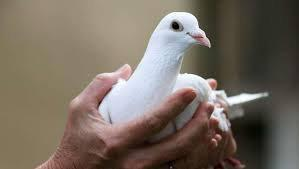
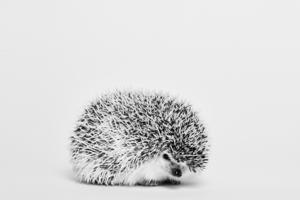
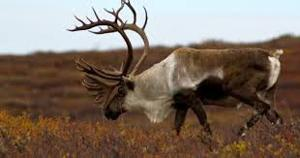
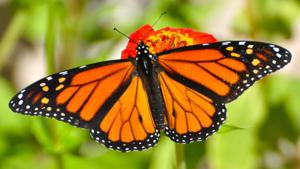
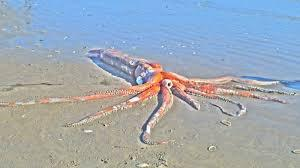
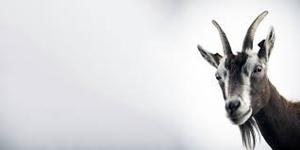
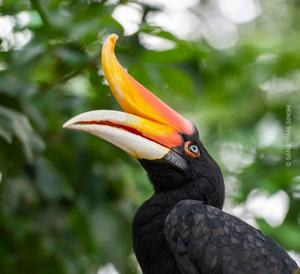
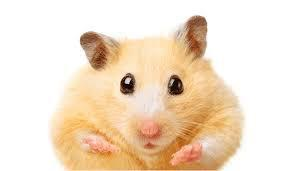
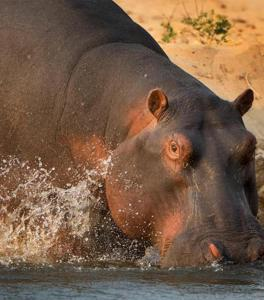
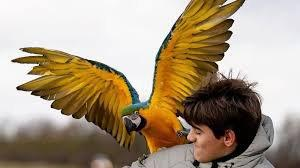

In [ ]:
# =================================================================
# CELL 6: TRỰC QUAN HÓA KẾT QUẢ ĐÁNH GIÁ (VISUALIZATION)
# =================================================================
import pandas as pd
import os
import base64
from io import BytesIO
from PIL import Image
from IPython.display import display, HTML

def generate_vqa_visualization(csv_path, num_samples=5):
    """
    Hàm đọc kết quả suy luận, mã hóa ảnh thành Base64 và khởi tạo giao diện HTML.

    Tham số:
    - csv_path: Đường dẫn tuyệt đối đến file kết quả B1_ZeroShot_Results.csv
    - num_samples: Số lượng mẫu ngẫu nhiên muốn hiển thị
    """
    print(f"Đang đọc dữ liệu từ: {csv_path}")

    # 1. Tải tệp dữ liệu kết quả thành cấu trúc DataFrame
    df_results = pd.read_csv(csv_path)

    # Rút trích ngẫu nhiên các mẫu dữ liệu. Sử dụng random_state=42 để
    # đảm bảo tính tất định (mỗi lần chạy đều ra cùng các mẫu để dễ so sánh).
    sample_df = df_results.sample(n=num_samples, random_state=42)

    # 2. Khởi tạo bộ khung HTML và CSS inline
    html_content = "<div style='display: flex; flex-direction: column; gap: 20px; font-family: Arial, sans-serif;'>"

    # 3. Lặp qua từng bản ghi dữ liệu
    for index, row in sample_df.iterrows():
        # Tái cấu trúc đường dẫn vật lý theo đúng chuẩn đã thiết lập ở Cell trước
        file_name = os.path.basename(row['image_path'])
        absolute_image_path = os.path.join(DATA_ROOT, 'test', row['label'], file_name)

        # Kiểm tra tính toàn vẹn của tệp ảnh trước khi xử lý
        if not os.path.exists(absolute_image_path):
            continue

        # 4. Đọc ảnh, thu nhỏ kích thước (để tối ưu RAM tĩnh của trình duyệt) và mã hóa Base64
        img = Image.open(absolute_image_path).convert("RGB")
        img.thumbnail((300, 300)) # Giới hạn kích thước tối đa là 300x300 pixels

        buffer = BytesIO()
        img.save(buffer, format="JPEG")
        img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')

        # 5. Logic xử lý định tính: Phân biệt màu sắc kết quả
        # Chuyển đổi toàn bộ văn bản về chữ thường và xóa khoảng trắng thừa ở hai đầu
        prediction_text = str(row['prediction']).strip()
        ground_truth_text = str(row['ground_truth']).strip()

        # Xác định sự khớp hoàn toàn (Exact Match) để gán mã màu CSS
        is_exact_match = (prediction_text.lower() == ground_truth_text.lower())

        # Màu xanh (Match) và Màu đỏ (Mismatch)
        pred_bg_color = "#d4edda" if is_exact_match else "#f8d7da"
        pred_text_color = "#155724" if is_exact_match else "#721c24"
        match_status = "Đúng (Exact Match)" if is_exact_match else "Sai lệch (Mismatch)"

        # 6. Lắp ghép các khối HTML cho từng mẫu
        html_content += f"""
        <div style='display: flex; border: 1px solid #ddd; padding: 15px; border-radius: 8px; box-shadow: 2px 2px 8px rgba(0,0,0,0.05); background-color: #fafafa;'>
            <div style='flex: 0 0 320px; text-align: center;'>
                <img src='data:image/jpeg;base64,{img_base64}' style='max-width: 300px; max-height: 300px; border-radius: 6px; border: 1px solid #ccc;'/>
                <p style='color: #666; font-size: 12px; margin-top: 5px;'>{row['image_path']}</p>
            </div>
            <div style='flex: 1; padding-left: 25px; display: flex; flex-direction: column; justify-content: center;'>
                <h3 style='margin-top: 0; color: #2c3e50; font-size: 18px;'>Q: {row['question']}</h3>
                <div style='margin-bottom: 10px; font-size: 14px; color: #555;'>
                    <span style='background-color: #e2e3e5; padding: 3px 8px; border-radius: 12px;'>Phân loại: {row['q_type']}</span>
                    <span style='margin-left: 10px; font-weight: bold; color: {pred_text_color};'>Trạng thái: {match_status}</span>
                </div>

                <div style='background-color: #e9ecef; padding: 10px 15px; border-radius: 5px; margin-bottom: 10px; border-left: 4px solid #adb5bd;'>
                    <strong style='color: #495057;'>Ground Truth (Nhãn gốc):</strong>
                    <div style='margin-top: 5px; font-size: 16px;'>{ground_truth_text}</div>
                </div>

                <div style='background-color: {pred_bg_color}; padding: 10px 15px; border-radius: 5px; border-left: 4px solid {pred_text_color};'>
                    <strong style='color: {pred_text_color};'>Prediction (AI Generate):</strong>
                    <div style='margin-top: 5px; font-size: 16px; color: {pred_text_color};'>{prediction_text}</div>
                </div>
            </div>
        </div>
        """

    html_content += "</div>"

    # Kết xuất toàn bộ mã HTML thành giao diện trực quan
    display(HTML(html_content))

# =================================================================
# THỰC THI HÀM
# =================================================================
# Đường dẫn tệp CSV đã được định nghĩa và lưu ở Cell 5
OUTPUT_CSV_PATH = "/content/drive/MyDrive/ENDTERM_DEEPLEARNING_OUTPUTS/B1/B1_ZeroShot_Results.csv"

# Gọi hàm hiển thị 10 mẫu ngẫu nhiên (bạn có thể thay đổi số lượng tùy ý)
generate_vqa_visualization(csv_path=OUTPUT_CSV_PATH, num_samples=10)